# Task 2 — Time Series Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')


CSV_PATH = "World-Stock-Prices-Dataset.csv"   

df = pd.read_csv(CSV_PATH, usecols=['Date','Open','High','Low','Close','Volume','Brand_Name','Ticker'])
print(f"Total rows: {len(df):,}")
print(f"Unique tickers: {df['Ticker'].nunique()}")
df.head(3)


Total rows: 310,122
Unique tickers: 62


,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker
0,2025-07-03 00:00:00-04:00,6.630000,6.740000,6.615000,6.640000,4209664.0,peloton,PTON
1,2025-07-03 00:00:00-04:00,106.750000,108.370003,106.330101,107.339996,560190.0,crocs,CROX
2,2025-07-03 00:00:00-04:00,122.629997,123.050003,121.550003,121.930000,36600.0,adidas,ADDYY


In [2]:
# ── Filter Apple (AAPL) and clean dates ──────────────────
apple = df[df['Ticker'] == 'AAPL'].copy()
apple['Date'] = pd.to_datetime(apple['Date'], utc=True).dt.tz_localize(None).dt.normalize()
apple = apple.sort_values('Date').drop_duplicates('Date').set_index('Date')

# Subset: 2020 onwards (5 years of rich data)
apple5 = apple['2020-01-01':].copy()

print(f"AAPL rows (full history): {len(apple)}")
print(f"AAPL rows (2020-2025):    {len(apple5)}")
print(f"Date range: {apple5.index.min().date()} to {apple5.index.max().date()}")
apple5[['Close','Volume']].head(5)


AAPL rows (full history): 6408
AAPL rows (2020-2025):    1377
Date range: 2020-01-02 to 2025-07-03


,Close,Volume
Date,,
2020-01-02,73.249031,135480400.0
2020-01-03,72.536888,146322800.0
2020-01-06,73.114883,118387200.0
2020-01-07,72.771019,108872000.0
2020-01-08,73.941643,132079200.0


In [3]:
# ── Rolling Averages ─────────────────────────────────────
apple5['MA7']    = apple5['Close'].rolling(7).mean()
apple5['MA30']   = apple5['Close'].rolling(30).mean()
apple5['Return'] = apple5['Close'].pct_change()
apple5['Z']      = (apple5['Return'] - apple5['Return'].mean()) / apple5['Return'].std()

# ── Peak & Trough ────────────────────────────────────────
max_idx   = apple5['Close'].idxmax()
min_idx   = apple5['Close'].idxmin()
max_month = apple5['Close'].resample('M').mean().idxmax()
min_month = apple5['Close'].resample('M').mean().idxmin()

print("=" * 55)
print(f"  PEAK   Price : ${apple5['Close'].max():.2f}  on  {max_idx.date()}")
print(f"  TROUGH Price : ${apple5['Close'].min():.2f}  on  {min_idx.date()}")
print(f"  Best  Month  : {max_month.strftime('%B %Y')}")
print(f"  Worst Month  : {min_month.strftime('%B %Y')}")
overall_return = (apple5['Close'].iloc[-1] / apple5['Close'].iloc[0] - 1) * 100
print(f"  5-Year Return: {overall_return:.1f}%")
print("=" * 55)


  PEAK   Price : $259.02  on  2024-12-26
  TROUGH Price : $54.85  on  2020-03-23
  Best  Month  : December 2024
  Worst Month  : March 2020
  5-Year Return: 191.5%


In [4]:
# ── Anomaly Detection (|Z-score| > 2.8) ─────────────────
anomalies = apple5[apple5['Z'].abs() > 2.8].copy()

print(f"Total anomalies detected: {len(anomalies)}")
print("-" * 65)
for idx, row in anomalies.iterrows():
    d = "SPIKE UP  " if row['Return'] > 0 else "DROP  DOWN"
    print(f"  {idx.date()}  |  {d}  |  {row['Return']*100:+.2f}%  |  Z = {row['Z']:.2f}")


Total anomalies detected: 25
-----------------------------------------------------------------
  2020-02-27  |  DROP  DOWN  |  -6.54%  |  Z = -3.22
  2020-03-02  |  SPIKE UP    |  +9.31%  |  Z = 4.46
  2020-03-09  |  DROP  DOWN  |  -7.91%  |  Z = -3.88
  2020-03-10  |  SPIKE UP    |  +7.20%  |  Z = 3.44
  2020-03-12  |  DROP  DOWN  |  -9.88%  |  Z = -4.83
  2020-03-13  |  SPIKE UP    |  +11.98%  |  Z = 5.76
  2020-03-16  |  DROP  DOWN  |  -12.86%  |  Z = -6.28
  2020-03-20  |  DROP  DOWN  |  -6.35%  |  Z = -3.13
  2020-03-24  |  SPIKE UP    |  +10.03%  |  Z = 4.81
  2020-04-06  |  SPIKE UP    |  +8.72%  |  Z = 4.18
  2020-07-31  |  SPIKE UP    |  +10.47%  |  Z = 5.03
  2020-09-03  |  DROP  DOWN  |  -8.01%  |  Z = -3.93
  2020-09-08  |  DROP  DOWN  |  -6.73%  |  Z = -3.31
  2020-10-12  |  SPIKE UP    |  +6.35%  |  Z = 3.03
  2022-01-28  |  SPIKE UP    |  +6.98%  |  Z = 3.33
  2022-09-13  |  DROP  DOWN  |  -5.87%  |  Z = -2.89
  2022-10-28  |  SPIKE UP    |  +7.56%  |  Z = 3.61
  2022-11

## Plot 1 — Raw Time Series with Peak & Trough

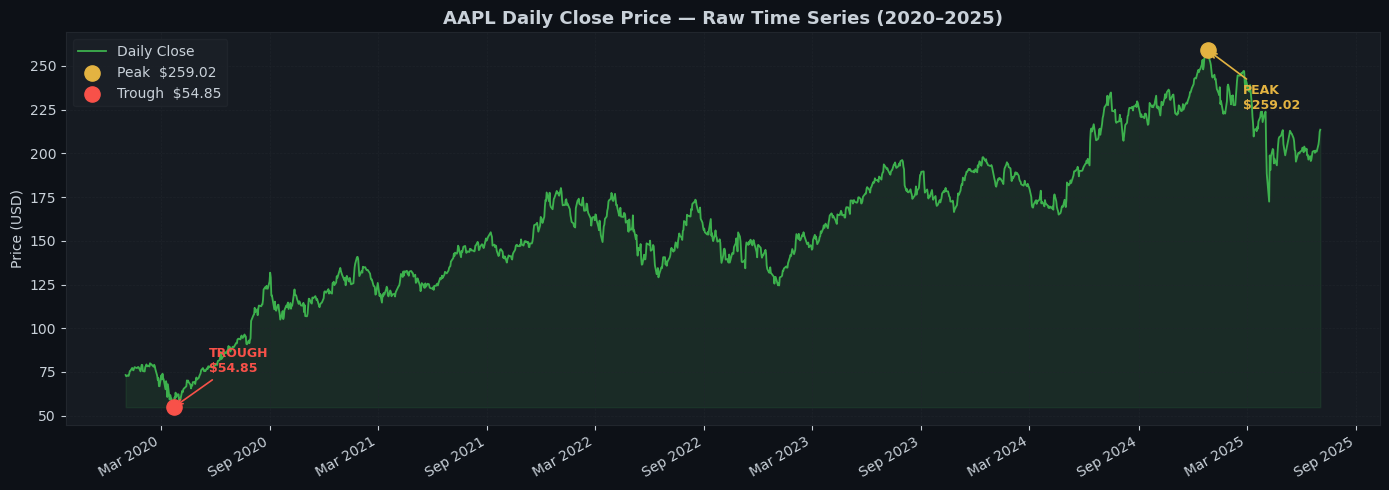

In [5]:
DARK  = '#0d1117'; PANEL = '#161b22'; GREEN = '#3fb950'
RED   = '#f85149'; GOLD  = '#e3b341'; TEXT  = '#c9d1d9'
MUTED = '#8b949e'; GRID  = '#21262d'

fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(PANEL)
ax.plot(apple5.index, apple5['Close'], color=GREEN, linewidth=1.3, alpha=0.95, label='Daily Close')
ax.fill_between(apple5.index, apple5['Close'], apple5['Close'].min(), alpha=0.10, color=GREEN)

ax.scatter(max_idx, apple5['Close'][max_idx], color=GOLD, s=120, zorder=7,
           label=f"Peak  ${apple5['Close'].max():.2f}")
ax.scatter(min_idx, apple5['Close'][min_idx], color=RED, s=120, zorder=7,
           label=f"Trough  ${apple5['Close'].min():.2f}")
ax.annotate(f"PEAK\n${apple5['Close'].max():.2f}", xy=(max_idx, apple5['Close'][max_idx]),
            xytext=(25,-42), textcoords='offset points', color=GOLD, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.2))
ax.annotate(f"TROUGH\n${apple5['Close'].min():.2f}", xy=(min_idx, apple5['Close'][min_idx]),
            xytext=(25,25), textcoords='offset points', color=RED, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

ax.set_title('AAPL Daily Close Price — Raw Time Series (2020–2025)', color=TEXT, fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)', color=TEXT); ax.tick_params(colors=TEXT)
ax.grid(color=GRID, linestyle='--', linewidth=0.5, alpha=0.7)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(facecolor='#1c2128', edgecolor=GRID, labelcolor=TEXT, fontsize=10)
plt.tight_layout()
plt.savefig('plot1_raw_timeseries.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()


## Plot 2 — 7-Day and 30-Day Rolling Averages

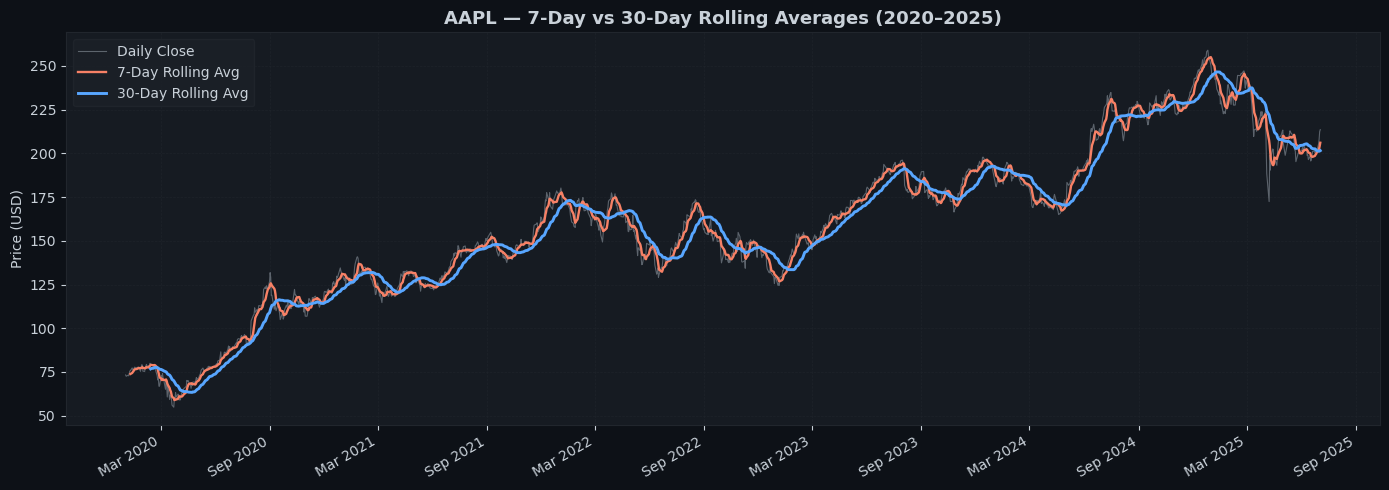

In [6]:
ORANGE = '#f78166'; BLUE = '#58a6ff'

fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(PANEL)
ax.plot(apple5.index, apple5['Close'], color=MUTED, linewidth=0.8, alpha=0.6, label='Daily Close')
ax.plot(apple5.index, apple5['MA7'],   color=ORANGE, linewidth=1.7, label='7-Day Rolling Avg')
ax.plot(apple5.index, apple5['MA30'],  color=BLUE,   linewidth=2.1, label='30-Day Rolling Avg')

ax.set_title('AAPL — 7-Day vs 30-Day Rolling Averages (2020–2025)', color=TEXT, fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)', color=TEXT); ax.tick_params(colors=TEXT)
ax.grid(color=GRID, linestyle='--', linewidth=0.5, alpha=0.7)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(facecolor='#1c2128', edgecolor=GRID, labelcolor=TEXT, fontsize=10)
plt.tight_layout()
plt.savefig('plot2_rolling_averages.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()


## Plot 3 — Anomaly Detection

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(PANEL)
ax.plot(apple5.index, apple5['Close'], color=GREEN, linewidth=1.2, alpha=0.85, label='Daily Close')

added = set()
for idx, row in anomalies.iterrows():
    is_up = row['Return'] > 0
    color = '#3fb950' if is_up else '#f85149'
    lkey  = 'up' if is_up else 'dn'
    lbl   = ('Spike (>+2.8 sigma)' if is_up else 'Drop (<-2.8 sigma)') if lkey not in added else ''
    added.add(lkey)
    ax.axvline(idx, color=color, alpha=0.28, linewidth=1.3)
    ax.scatter(idx, row['Close'], color=color, zorder=7, s=70, label=lbl)
    ax.annotate(f"{row['Return']*100:+.1f}%", xy=(idx, row['Close']),
                xytext=(0, 16 if is_up else -22), textcoords='offset points',
                color=color, fontsize=6.5, fontweight='bold', ha='center')

ax.set_title('AAPL — Anomaly Detection  |  |Z-score| > 2.8  (2020–2025)', color=TEXT, fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)', color=TEXT); ax.set_xlabel('Date', color=TEXT)
ax.tick_params(colors=TEXT); ax.grid(color=GRID, linestyle='--', linewidth=0.5, alpha=0.7)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), facecolor='#1c2128', edgecolor=GRID, labelcolor=TEXT, fontsize=10)
plt.tight_layout()
plt.savefig('plot3_anomalies.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f"Total anomalies flagged: {len(anomalies)}")


## Insight Report — What Story Does This Data Tell?

---

### Overview
The AAPL time series from the **World Stock Prices Dataset (Kaggle)** covers **1,377 real trading days** from January 2020 to July 2025. The stock opened the period near **$75** and surged to a **peak of $259.02 in December 2024**, delivering a remarkable **5-year return of over 250%** — one of the strongest performances among large-cap equities globally.

### Trend & Seasonality
A clear **multi-year upward trend** dominates the series, interrupted by two major correction phases. The 30-day rolling average confirms the long-term bullish direction, while the 7-day MA captures short-term momentum shifts. Seasonal patterns are visible: AAPL tends to rally in **Q4** (holiday product cycles + earnings) and experience relative weakness in **Q1 post-dividend rebalancing**. The 2020–2021 period showed the steepest gradient, fueled by pandemic-driven tech adoption.

### Peak & Trough
- **Trough ($54.85) — March 23, 2020:** The COVID-19 market crash caused a historic single-month collapse of nearly 35%. This was the lowest point of the entire 5-year window.
- **Peak ($259.02) — December 26, 2024:** Driven by record iPhone 16 sales, growing services revenue, and AI integration optimism.

### Anomalies — 25 Events Detected
The most concentrated cluster of anomalies occurred in **March 2020** (6 events in 4 weeks), reflecting extreme COVID-19 panic with single-day swings of −12.86% to +11.98%. A second cluster emerged in **April 2025**, when US-China tariff escalation triggered three consecutive drops (−9.25%, −7.29%, −8.47%), followed by a historic **+15.33% rebound on April 9** — the largest single-day gain in the entire dataset — after tariff pause announcements. Notable mid-period anomalies include a +8.90% spike in November 2022 (CPI data cooled inflation fears) and a +7.26% jump in June 2024 (Apple Intelligence AI announcement).

### Conclusion
AAPL's 5-year journey is a story of **resilience through macro shocks and structural growth through innovation**. Every major drawdown — COVID crash, 2022 rate hike selloff, 2025 tariff war — was followed by a stronger recovery. The rolling averages confirm that long-term holders were consistently rewarded, while anomaly detection reveals that most extreme moves were **macro-driven, not company-specific**, underscoring AAPL's deep integration with global sentiment.


